# 🧠 Modelo 5: Transfer Learning Avanzado con ResNet50

En este notebook utilizamos la arquitectura **ResNet50** (una de las más potentes en visión por computador) preentrenada en ImageNet. Aplicamos **Learning Rate Scheduling** y evaluamos su desempeño con métricas especializadas (AUC).

---

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix

# Añadir el directorio raíz al path para importar módulos locales
sys.path.append('..')
import oct_dataloader as dataloaders
import modelos.modelo_resnet50_unfrozen as resnet_model

print("✅ Librerías e importaciones listas")

2026-03-12 09:05:22.226716: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 09:05:22.272264: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 09:05:23.233221: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ Librerías e importaciones listas


In [2]:
# Configurar GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detectada(s): {(gpu)}")
    except RuntimeError as e:
        print(e)
else:
    print(" No se detectó GPU. Se usará la CPU.")

GPU detectada(s): PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')


## 1. Carga de Datos (RGB para ResNet50)

**IMPORTANTE**: ResNet50 está diseñado para imágenes en color (3 canales). Por ello, configuramos `color_mode='rgb'` en el dataloader.

In [3]:
# Descargar/Localizar dataset
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")
data_path = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        data_path = root
        break

# Configuración del DataLoader
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SUBSET = 0.8 # Usamos el 30% del entrenamiento para que sea fluido

train_ds, val_ds, test_ds, class_names = dataloaders.create_oct_dataloaders(
    data_path=data_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb', # <--- OBLIGATORIO para ResNet50
    train_subset_fraction=SUBSET, 
    optimize=False
)

⚙️ Configuración de DataLoaders
   • Tamaño de imagen: (224, 224)
   • Batch size: 16
   • Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
   • Train subset: 80.0%
   • Seed: 42

📦 Creando data loader de entrenamiento...
Found 76515 files belonging to 4 classes.


I0000 00:00:1773302726.607651 1141078 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78844 MB memory:  -> device: 0, name: NVIDIA H100 PCIe, pci bus id: 0000:05:00.0, compute capability: 9.0
I0000 00:00:1773302726.616942 1141078 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 78844 MB memory:  -> device: 1, name: NVIDIA H100 PCIe, pci bus id: 0000:09:00.0, compute capability: 9.0
I0000 00:00:1773302726.619346 1141078 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 78844 MB memory:  -> device: 2, name: NVIDIA H100 PCIe, pci bus id: 0000:8d:00.0, compute capability: 9.0
I0000 00:00:1773302726.621682 1141078 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 78844 MB memory:  -> device: 3, name: NVIDIA H100 PCIe, pci bus id: 0000:91:00.0, compute capability: 9.0
E0000 00:00:1773302726.751025 1141545 ptx_compiler_helpers.cc:88] *** WARNING *** In

   ⚠️  Usando 80.0% del dataset de entrenamiento
   ⚠️  Batches: 3826 de 4783
✅ Data loader de entrenamiento creado

📦 Creando data loader de validación...
Found 21861 files belonging to 4 classes.
✅ Data loader de validación creado

📦 Creando data loader de prueba...
Found 10933 files belonging to 4 classes.
✅ Data loader de prueba creado

📊 RESUMEN DE DATASETS
Train:      3826 batches
Validation: 1367 batches
Test:       684 batches



## 2. Creación y Compilación del Modelo

ResNet50 tiene millones de parámetros. Congelamos su base para realizar solo **Transfer Learning** sobre las capas superiores que hemos añadido.

In [4]:
from tensorflow.keras.metrics import AUC

# Hiperparámetros configurables
LEARNING_RATE = 3e-5
DROPOUT = 0.4

# 1. Crear el modelo con ResNet50
model = resnet_model.create_resnet_model(
    input_shape=(224, 224, 3), # (Ancho, Alto, Canales RGB)
    num_classes=4, 
    dropout_rate=DROPOUT
)

# 2. Compilar especificando métricas (incluyendo el AUC para mayor robustez)
metrics = [
    'accuracy'
]

model = resnet_model.compile_resnet_model(
    model, 
    learning_rate=LEARNING_RATE, 
    metrics=metrics
)

model.summary()

Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,308 (91.99 MB)

 Trainable params: 24,060,676 (91.78 MB)

 Non-trainable params: 53,632 (209.50 KB)

## 3. Entrenamiento con Scheduler

Implementamos `ReduceLROnPlateau` para mejorar la estabilidad del entrenamiento.

In [6]:
EPOCHS = 100

# Obtener callbacks avanzados
callbacks = resnet_model.get_resnet_callbacks(
    patience_stop=5, 
    patience_lr=2, 
    factor_lr=0.2
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/100
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8541 - loss: 0.4234
Epoch 1: val_loss improved from None to 0.11101, saving model to modelos/best_resnet50.weights.h5

Epoch 1: finished saving model to modelos/best_resnet50.weights.h5
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 103s 27ms/step - accuracy: 0.9223 - loss: 0.2401 - val_accuracy: 0.9650 - val_loss: 0.1110 - learning_rate: 3.0000e-05
Epoch 2/100
3824/3826 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9633 - loss: 0.1128
Epoch 2: val_loss improved from 0.11101 to 0.08871, saving model to modelos/best_resnet50.weights.h5

Epoch 2: finished saving model to modelos/best_resnet50.weights.h5
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 99s 26ms/step - accuracy: 0.9674 - loss: 0.1013 - val_accuracy: 0.9699 - val_loss: 0.0887 - learning_rate: 3.0000e-05
Epoch 3/100
3825/3826 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9784 - loss: 0.0717
Epoch 3: val_loss did not improve from 0.08871
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 100s 26ms/step - a

## 4. Curvas de Aprendizaje y Evaluación

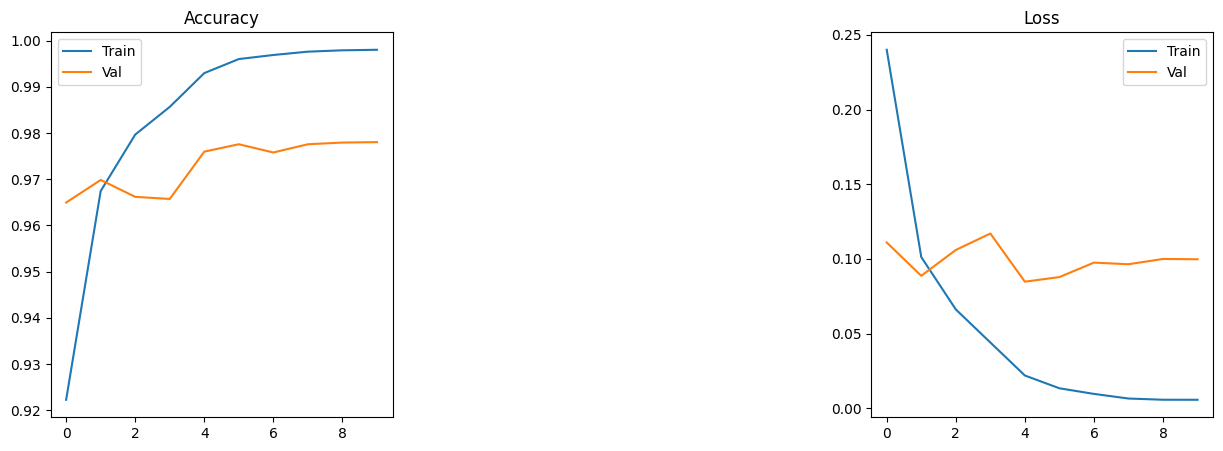

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()



plt.subplot(1, 3, 3)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.show()

Loss en test: 0.0961
Accuracy en test: 0.9748

AUC por clase (One-vs-Rest):
 - CNV: 0.9982
 - DME: 0.9980
 - DRUSEN: 0.9927
 - NORMAL: 0.9991

AUC Promedio (Macro): 0.9970

Reporte de clasificacion:
              precision    recall  f1-score   support

         CNV       0.98      0.98      0.98      3746
         DME       0.97      0.96      0.96      1161
      DRUSEN       0.90      0.89      0.90       887
      NORMAL       0.99      0.99      0.99      5139

    accuracy                           0.97     10933
   macro avg       0.96      0.95      0.96     10933
weighted avg       0.97      0.97      0.97     10933



2026-03-12 09:24:12.189403: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


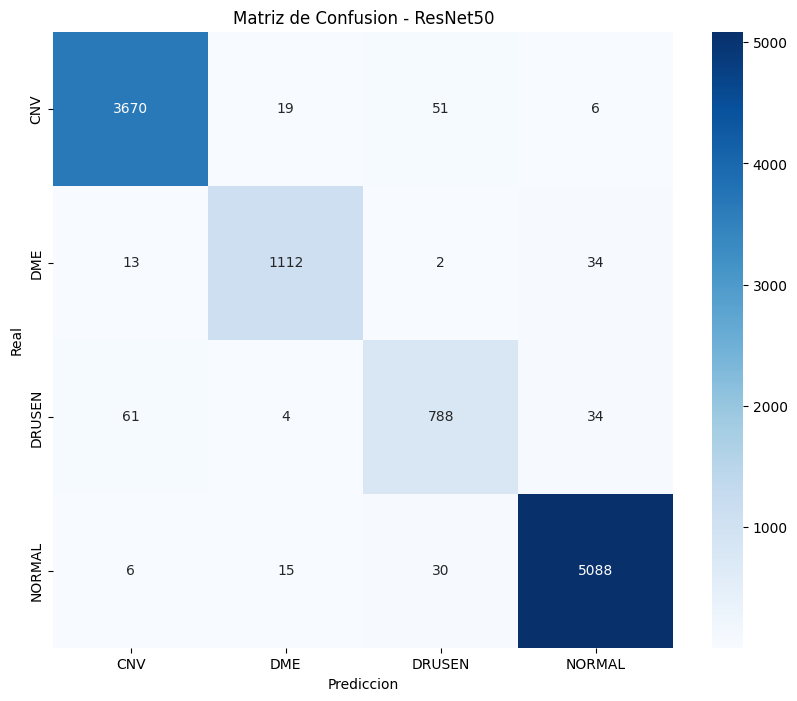

In [8]:
# --- Chunk: Evaluacion de Metricas Finales ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical

results = model.evaluate(test_ds, verbose=0)
print(f"Loss en test: {results[0]:.4f}")
print(f"Accuracy en test: {results[1]:.4f}")

y_true = []
y_probs = []

# Obtencion de predicciones
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_probs.extend(preds)

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = np.argmax(y_probs, axis=1)

# Calculo de AUC por clase
y_true_oh = to_categorical(y_true, num_classes=len(class_names))
print("\nAUC por clase (One-vs-Rest):")
auc_scores = []
for i, class_name in enumerate(class_names):
    auc = roc_auc_score(y_true_oh[:, i], y_probs[:, i])
    auc_scores.append(auc)
    print(f" - {class_name}: {auc:.4f}")

print(f"\nAUC Promedio (Macro): {np.mean(auc_scores):.4f}")

# Reporte de Clasificacion
print("\nReporte de clasificacion:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de Confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusion - ResNet50')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()
